In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

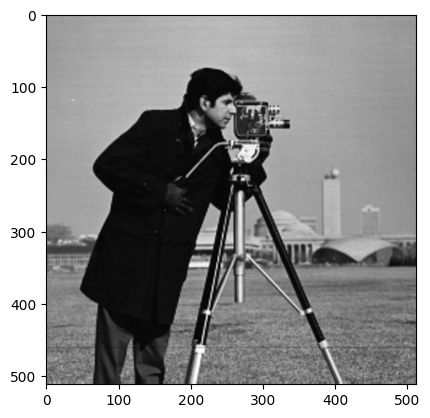

In [4]:
img = cv2.imread('cameraman.tif')
plt.imshow(img, cmap='gray')

In [6]:
img.shape

(512, 512, 3)

### Convolution Function

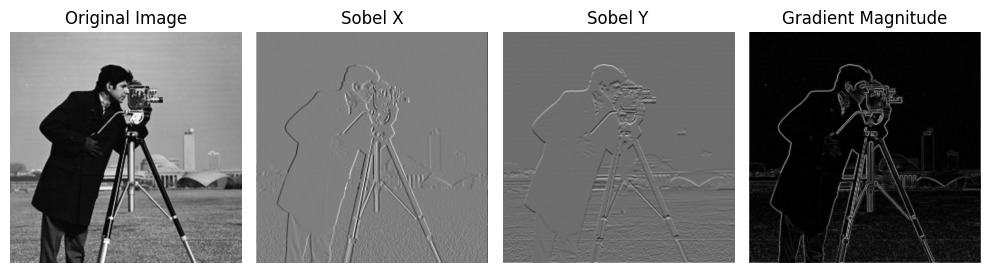

In [ ]:
def convolution2d(image, kernel, padding='same', dilation=1):

    if len(image.shape) > 2:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Get image and kernel dimensions
    h_img, w_img = image.shape
    h_kernel, w_kernel = kernel.shape
    
    # Calculate padding
    if padding == 'same':
        pad_h = ((h_kernel - 1) * dilation) // 2
        pad_w = ((w_kernel - 1) * dilation) // 2
    else:  # 'valid' padding
        pad_h, pad_w = 0, 0
    
    # Calculate output dimensions
    h_out = h_img + 2 * pad_h - (h_kernel - 1) * dilation
    w_out = w_img + 2 * pad_w - (w_kernel - 1) * dilation
    
    # Create padded image
    padded_img = np.zeros((h_img + 2 * pad_h, w_img + 2 * pad_w))
    padded_img[pad_h:pad_h + h_img, pad_w:pad_w + w_img] = image
    
    # Initialize output
    output = np.zeros((h_out, w_out))
    
    # Perform convolution
    for i in range(h_out):
        for j in range(w_out):
            sum_val = 0
            for k in range(h_kernel):
                for l in range(w_kernel):
                    row = i + k * dilation
                    col = j + l * dilation
                    if 0 <= row < h_img + 2 * pad_h and 0 <= col < w_img + 2 * pad_w:
                        sum_val += padded_img[row, col] * kernel[k, l]
            output[i, j] = sum_val
    
    return output

# Example usage:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2], 
                    [-1, 0, 1]])

sobel_y = np.array([[1, 2, 1],
                    [0, 0, 0], 
                    [-1, -2, -1]])

result_x = convolution2d(img, sobel_x)
result_y = convolution2d(img, sobel_y)

result = np.sqrt(result_x**2 + result_y**2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 4, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Sobel X')
plt.imshow(result_x, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Sobel Y')
plt.imshow(result_y, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Gradient Magnitude') 
plt.imshow(result, cmap='gray')
plt.axis('off')

plt.tight_layout()
